# Data Visualizations

### **All exercises will be using your chosen dataset**

## Step 1: Import your dataset using the tutorial from the slides

## Step 2: Install necessary libraries. New libraries are Matplotlib and Seaborn for week 2. We will also use scikit-learn for Principal Component Analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Exercises

### Documentation for Reference

#### [Pandas](https://pandas.pydata.org/docs/)

#### [NumPy](https://numpy.org/devdocs/)

#### [Matplotlib](https://matplotlib.org/stable/)

#### [Seaborn](https://seaborn.pydata.org/)

#### [Scikit-Learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)


In Machine Learning, the target **y** is the variable that the model is trying to predict given a set of features **X**. In regression tasks, **y** is a numerical value and in classification, it is a categorical value. Identify the target variable that you are using and state what type it is.

### Exercise 1: Correlations

In [ ]:
# TODO: Read dataset into a Pandas dataframe
og = pd.read_csv('healthcare-dataset-stroke-data.csv')
df = og.select_dtypes(exclude = ['object', 'string'])

<Axes: >

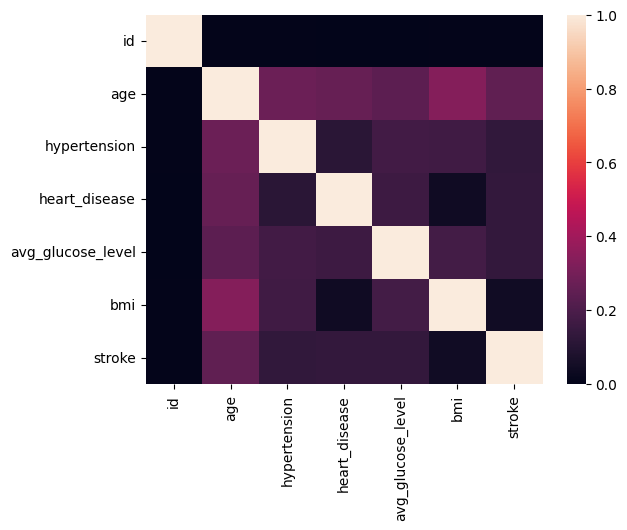

In [ ]:
# TODO: Create a correlation matrix heatmap (you first need to use df.corr()). Use sns for visualizing the heatmap)
# Keep in mind that these correlations highlight linear relationships between variables
cor_matrix = df.corr()
sns.heatmap(cor_matrix)

(array([2., 3., 1., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.00638817, 0.10574935, 0.20511054, 0.30447172, 0.4038329 ,
        0.50319409, 0.60255527, 0.70191645, 0.80127763, 0.90063882,
        1.        ]),
 <BarContainer object of 10 artists>)

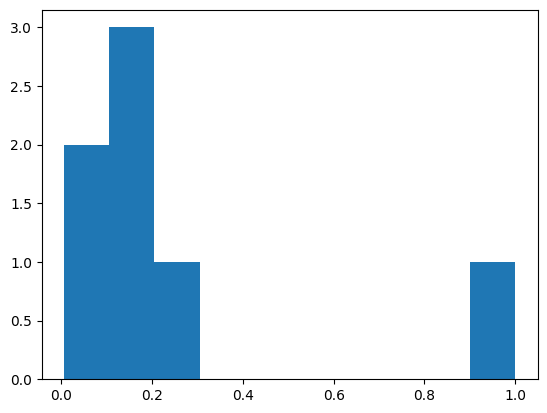

In [ ]:
# TODO: Plot a histogram of the correlations of all features related to the desired target variable.
# Use matrix["target"] and matplotlib's plt.hist() for the histogram
plt.hist(cor_matrix['stroke'])

Which feature(s) are highly correlated to the target?

### Exercise 2: Numerical Feature Visualizations

Text(0.5, 1.0, 'Distribution of Age')

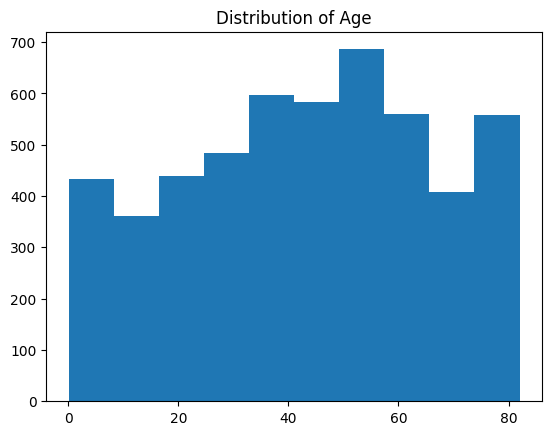

In [ ]:
# TODO: Identify one numerical feature to work with and plot a distribution of this feature using plt.hist() or sns.histplot().
# Also, use plt.title() to name this graph
plt.hist(df['age'])
plt.title('Distribution of Age')

<Axes: xlabel='age', ylabel='Proportion'>

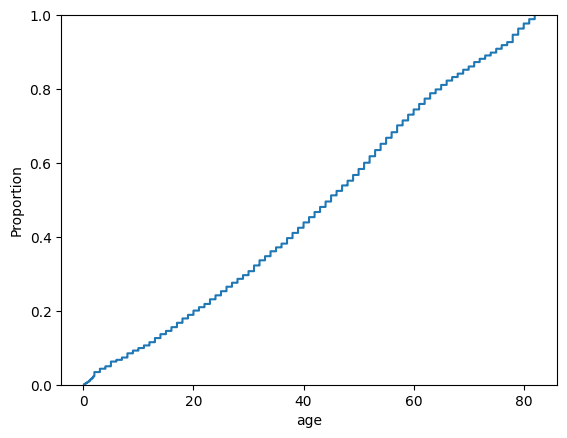

In [ ]:
# TODO: Plot an ECDF graph using seaborn - sns.ecdfplot(). Ths stands for Empirical Cumulative Distribution function.
sns.ecdfplot(df['age'])

<Axes: xlabel='avg_glucose_level', ylabel='Proportion'>

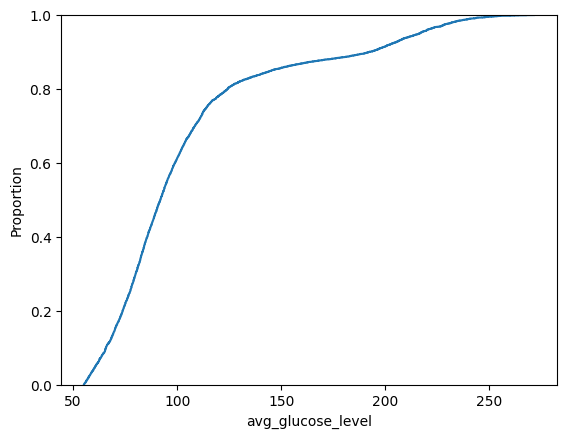

In [ ]:
sns.ecdfplot(df['avg_glucose_level'])

How is the feature distributed? A **uniform distribution** means that the **histogram** is level and the **ECDF** is a straight line. If possible, identify anything that might hint at bias in the sampling of this data such as abnormally high or abnormally low values that are present in the distribution.

### Exercise 3: Categorical Feature Visualizations

<Axes: xlabel='count', ylabel='work_type'>

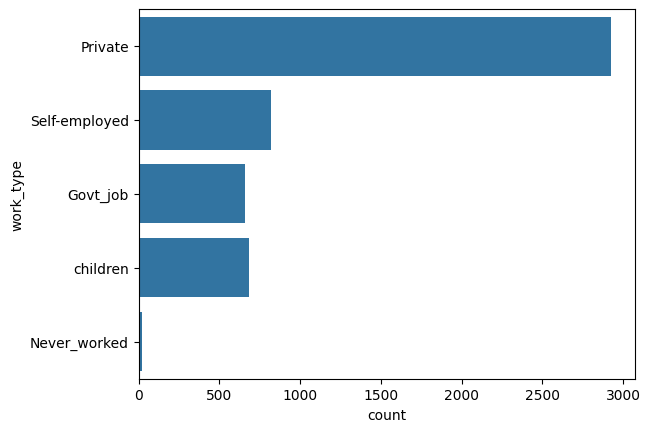

In [ ]:
# TODO: Identify one categorical feature to work with and plot a distribution of it using sns.countplot().
# If you don't have aa categorical variable, you can use pd.cut() to create one. 
sns.countplot(og['work_type'])

Same as before, determine how the categories are distributed and highlight any biases that seem present.

### Exercise 4: Target vs. Numerical Feature


#### Use the previous numerical feature and the chosen target to create the following visualizations.

**Do these exercises if your target is numerical**

In [ ]:
# TODO: Create a seaborn or matplotlib scatterplot plot (scatterplot()) which shows a graphical relationship between these two variables.

In [ ]:
# TODO: Create a matplotlib scatter plot (pyplot.scatter()). Use plt.xlabel and plt.ylabel

In [ ]:
# TODO: Create a seaborn lmplot() which creates a regression line for the the scattered data

Write down insights into how these variables are related (or not).

**Do these exercises if your target is categorical**

In [ ]:
# TODO: Create a seaborn boxplot() for the two variables


In [ ]:
# TODO: Create a seaborn violinplot() which shows the distribution of the numerical data

Write down insights into how these variables are related (or not).

### Exercise 5: Target vs. Categorical Feature

#### Use the previous categorical feature  and the chosen target to create the following visualizations.

**Do these exercises if your target is numerical**

In [ ]:
# TODO: Create a seaborn boxplot() for these two variables

In [ ]:
# TODO: Create a seaborn violinplot(). Use inner="quartile" to view the percentiles of the distribution

Write down insights into how these variables are related (or not).

**Do these exercises if your target is categorical**

In [ ]:
# TODO: Use pd.crosstab() which creates a frequency table of the categorical variables

In [ ]:
# TODO: Using the crosstab above, create a seaborn heatmap() which visualizes this relationship

Write down insights into how these variables are related (or not).

### Exercise 6: Principal Component Analysis

Principal Component Analysis is a powerful tool mainly used for dimensionality reduction by transforming the data into principal components (uncorrelated features) which are combinations of the original features in the data. In our case, we will be using it to create a 2d visualization of the data we are using.

In [ ]:
# TODO: Use pandas to drop the target variable and put this into a variable X_data.
X_data = ...

Before doing PCA, we need to encode the categorical variables. One way of doing this is one-hot encoding which turns the variables into numerical 1's and 0's for the algorithm to understand.

In [ ]:
# TODO: get_dummies is one-hot encoding the categorical variables
# Also, put the target varible into the y_data variable

X_data = pd.get_dummies(X_data, drop_first = True)
y_data = ...

In [ ]:
# TODO: This makes sure all features contribute equally for the analysis

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

In [ ]:
# TODO: The first line initializes the pca algorithm.
# the second line creates the principal components

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

We can determine how many PCs we need based on a variance explanation threshold. We do this by plotting a cumulative density plot of explained variance.

In [ ]:
# TODO: Use plt.plot() to plot 'np.cumsum(pca.explained_variance_ratio_)'

The y-axis is the variance (the spread) of the original data. How many principal components are needed to explain ~90% of the variance in your data?

In [ ]:
# TODO: These lines are for graphing first two principal components

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# TODO: This code creates a scatterplot of the first two principal components using sns.scatterplot().

df_pca = pd.DataFrame(X_pca)
df_pca["target"] = y_data
sns.scatterplot(data=df_pca, x=0, y=1, hue='target')

The x-axis is the first PC and the y-axis is the second PC. If your target was categorical, Identify if the clusters between the categories are noticeable. If your target was numerical, determine if the color gradient varies smoothly along the principal components. Note that points that are close together have similar data profiles.

This last line of code gives us the features that were involved in the first principal component. Note that the first principal component is designed to capture the maximum possible variance.

In [ ]:
# Define the loadings for each feature on each Principal Component (the correlations of each feature in PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_data.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Show the top-contributing features for PC1
loadings["PC1"].sort_values(ascending=False).head(10)

In [ ]:
df.to_csv("cleaned_healthcare_data.csv")

What is the highest correlated feature in PC1?

### Exercise 7: Further Visualizations

#### Continue creating data visualizations for other other features and further understand your data! Utilize the documentation.